In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Define the CNN + LSTM Model
class CNN_LSTM_EmotionModel(nn.Module):
    def __init__(self, input_size, num_classes, cnn_output_dim=64, lstm_hidden_size=128, lstm_layers=2):
        super(CNN_LSTM_EmotionModel, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=cnn_output_dim, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=cnn_output_dim, out_channels=cnn_output_dim, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.lstm = nn.LSTM(input_size=cnn_output_dim, hidden_size=lstm_hidden_size, num_layers=lstm_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(lstm_hidden_size * 2, num_classes)
    
    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)  # Reshape for LSTM (batch, sequence, feature)
        x, _ = self.lstm(x)
        x = self.fc(x[:, -1, :])  # Take last timestep output
        return x

# Load Data
class SpeechEmotionDataset(Dataset):
    def __init__(self, csv_path):
        self.data = pd.read_csv(csv_path)
        self.features = self.data.iloc[:, :-1].values  # All feature columns
        self.labels = self.data.iloc[:, -1].values  # Label column

        # Encode labels as integers
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.labels)

        self.features = np.expand_dims(self.features, axis=1)  # Ensure shape (batch, 1, seq_len)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.features[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

# Load Dataset
csv_path = "mel_spectrogram_features.csv"
dataset = SpeechEmotionDataset(csv_path)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Model, Loss, Optimizer
input_size = dataset.features.shape[2]  # Fix input dimension extraction
num_classes = len(np.unique(dataset.labels))
model = CNN_LSTM_EmotionModel(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, epochs=50):
    best_val_acc = 0.0
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs = inputs  # No need to squeeze
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        train_acc = 100 * correct / total
        
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs  # No need to squeeze
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_acc = 100 * correct / total
        
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(val_loader):.4f}, Train Accuracy: {train_acc:.2f}%, Validation Accuracy: {val_acc:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print("Model Saved!")
    
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

# Train Model
train_model(model, train_loader, val_loader, epochs=50)

Epoch [1/50], Train Loss: 2.7304, Validation Loss: 2.6517, Train Accuracy: 6.68%, Validation Accuracy: 10.76%
Model Saved!
Epoch [2/50], Train Loss: 2.6082, Validation Loss: 2.5704, Train Accuracy: 10.07%, Validation Accuracy: 12.85%
Model Saved!
Epoch [3/50], Train Loss: 2.5475, Validation Loss: 2.5374, Train Accuracy: 12.24%, Validation Accuracy: 8.33%
Epoch [4/50], Train Loss: 2.5207, Validation Loss: 2.4883, Train Accuracy: 12.41%, Validation Accuracy: 14.58%
Model Saved!
Epoch [5/50], Train Loss: 2.5092, Validation Loss: 2.5043, Train Accuracy: 13.02%, Validation Accuracy: 11.81%
Epoch [6/50], Train Loss: 2.4881, Validation Loss: 2.4635, Train Accuracy: 13.11%, Validation Accuracy: 15.28%
Model Saved!
Epoch [7/50], Train Loss: 2.4822, Validation Loss: 2.5107, Train Accuracy: 12.67%, Validation Accuracy: 13.89%
Epoch [8/50], Train Loss: 2.4624, Validation Loss: 2.4360, Train Accuracy: 15.36%, Validation Accuracy: 15.97%
Model Saved!
Epoch [9/50], Train Loss: 2.4484, Validation Loss

In [2]:
import os
import librosa
import numpy as np
import pandas as pd

# Define path
data_path = r"C:\Users\ASUS\OneDrive\Desktop\project\speech_emotion_recognition_ravdess_data (1)"

# Function to extract features
def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)  # Load audio
        if y is None or len(y) == 0:
            return None  # Skip empty audio files
        
        mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)  # MFCCs
        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)  # Chroma
        mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr), axis=1)  # Mel Spectrogram
        contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr), axis=1)  # Spectral Contrast

        # Combine all features into a single vector
        feature_vector = np.hstack([mfcc, chroma, mel, contrast])
        return feature_vector
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Emotion mapping
emotion_dict = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}

# Process all WAV files
data = []
num_features = None  # Track number of features dynamically

for root, _, files in os.walk(data_path):  # Search all subdirectories
    for file in files:
        # Process only files with "_noisy_stretched" in the name
        if file.endswith(".wav") and "noisy_stretched" in file:
            file_path = os.path.join(root, file)
            features = extract_features(file_path)

            if features is None:
                continue  # Skip if features could not be extracted

            if num_features is None:
                num_features = len(features)  # Store the feature vector length

            # Extract emotion and actor ID from filename
            parts = file.split("-")
            if len(parts) != 7:
                print(f"Skipping {file}: Incorrect filename format")
                continue  # Skip invalid filenames

            # Extract the emotion and actor from the filename
            emotion_code = parts[2]  # Emotion is at index 2
            actor_code = int(parts[-2])  # Actor ID is at the second-to-last position

            # Get the emotion and gender
            emotion = emotion_dict.get(emotion_code, "unknown")  # Get emotion label
            gender = "male" if actor_code % 2 == 1 else "female"  # Male if odd, female if even
            label = f"{gender}-{emotion}"  # Format label as "male-emotion" or "female-emotion"

            # Add features and label to the data list
            data.append(list(features) + [label])

# Ensure at least one valid entry exists
if not data:
    print("No valid audio files processed. Check the dataset.")
else:
    # Define column names dynamically
    columns = [f"feature_{i}" for i in range(num_features)] + ["label"]

    # Save features to CSV
    df = pd.DataFrame(data, columns=columns)
    df.to_csv("sample1.csv", index=False)

    print("Feature extraction complete. Saved to 'sample1.csv'.")


Feature extraction complete. Saved to 'sample1.csv'.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np

# Load your CSV file with features and labels
CSV_PATH = 'sample1.csv'
df = pd.read_csv(CSV_PATH)

# Extract features and labels
X = df.drop('label', axis=1).values  # Features (all columns except 'label')
y = df['label'].values  # Labels

# Label encoding
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Encoding labels

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Create a custom Dataset for loading the features and labels
class SpeechEmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Define the CNN+LSTM-based model with added features
class CNNLSTMEmotionModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CNNLSTMEmotionModel, self).__init__()
        
        # CNN Layers
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout_cnn = nn.Dropout(0.4)

        # LSTM Layer
        self.lstm = nn.LSTM(input_size=128, hidden_size=128, bidirectional=True, batch_first=True)
        self.dropout_lstm = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 2, 512)  # Bidirectional LSTM doubles the hidden size
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add a channel dimension (batch_size, 1, features)
        
        # CNN layers
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.bn1(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.bn2(x)
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.bn3(x)
        x = self.dropout_cnn(x)

        # LSTM layer
        x = x.permute(0, 2, 1)  # Change shape to (batch_size, seq_len, features) for LSTM
        x, _ = self.lstm(x)  # LSTM output (batch_size, seq_len, hidden_size)
        x = self.dropout_lstm(x)
        x = x[:, -1, :]  # Get the output of the last time step

        # Fully connected layers
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

# Initialize the model
input_dim = X_train.shape[1]
num_classes = len(label_encoder.classes_)
model = CNNLSTMEmotionModel(input_dim, num_classes)

# Loss function and optimizer with L2 regularization (weight decay)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# DataLoader for training and validation
train_dataset = SpeechEmotionDataset(X_train_tensor, y_train_tensor)
val_dataset = SpeechEmotionDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

# Training loop with early stopping
best_val_accuracy = 0
patience = 5  # Allow for more patience before early stopping
epochs_without_improvement = 0
num_epochs = 50  # Increase epochs for more training

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0

    for data in train_loader:
        inputs, labels = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(val_loader):.4f}, Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {val_accuracy:.2f}%")

    # Check if validation accuracy improves
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_cnn_lstm_model.pth')
    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= patience:
        print("Early stopping triggered!")
        break

    # Step the scheduler
    scheduler.step(val_loss)

print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")


Epoch [1/50], Train Loss: 2.7510, Validation Loss: 2.7180, Train Accuracy: 7.38%, Validation Accuracy: 7.99%
Epoch [2/50], Train Loss: 2.6726, Validation Loss: 2.6829, Train Accuracy: 10.59%, Validation Accuracy: 11.11%
Epoch [3/50], Train Loss: 2.6117, Validation Loss: 2.6685, Train Accuracy: 11.63%, Validation Accuracy: 13.19%
Epoch [4/50], Train Loss: 2.5745, Validation Loss: 2.6059, Train Accuracy: 13.80%, Validation Accuracy: 12.85%
Epoch [5/50], Train Loss: 2.5241, Validation Loss: 2.5797, Train Accuracy: 16.58%, Validation Accuracy: 12.50%
Epoch [6/50], Train Loss: 2.4623, Validation Loss: 2.5305, Train Accuracy: 15.71%, Validation Accuracy: 16.67%
Epoch [7/50], Train Loss: 2.4291, Validation Loss: 2.5093, Train Accuracy: 17.71%, Validation Accuracy: 13.89%
Epoch [8/50], Train Loss: 2.3821, Validation Loss: 2.4686, Train Accuracy: 21.01%, Validation Accuracy: 16.32%
Epoch [9/50], Train Loss: 2.3503, Validation Loss: 2.4474, Train Accuracy: 20.14%, Validation Accuracy: 15.97%
Epo

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load your CSV file with features and labels
CSV_PATH = 'speech_emotion_features.csv'
df = pd.read_csv(CSV_PATH)

# Extract features and labels
X = df.drop('label', axis=1).values  # Features (all columns except 'label')
y = df['label'].values  # Labels

# Label encoding (if your labels are categorical)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Encoding labels

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Create a custom Dataset for loading the features and labels
class SpeechEmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Define the CNN+LSTM-based model
class CNNLSTMEmotionModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CNNLSTMEmotionModel, self).__init__()
        
        # CNN Layers (Modified)
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, stride=1, padding=1)  # Increased filters
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1)  # Increased filters
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, stride=1, padding=1)  # Increased filters
        self.bn3 = nn.BatchNorm1d(256)
        self.dropout_cnn = nn.Dropout(0.4)

        # LSTM Layer (Modified hidden size)
        self.lstm = nn.LSTM(input_size=256, hidden_size=256, bidirectional=True, batch_first=True)
        self.dropout_lstm = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(256 * 2, 512)  # Adjusted for bidirectional LSTM
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add a channel dimension (batch_size, 1, features)
        
        # CNN layers
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.bn1(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.bn2(x)
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.bn3(x)
        x = self.dropout_cnn(x)

        # LSTM layer
        x = x.permute(0, 2, 1)  # Change shape to (batch_size, seq_len, features) for LSTM
        x, _ = self.lstm(x)  # LSTM output (batch_size, seq_len, hidden_size)
        x = self.dropout_lstm(x)
        x = x[:, -1, :]  # Get the output of the last time step

        # Fully connected layers
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

# Initialize the model
input_dim = X_train.shape[1]
num_classes = len(label_encoder.classes_)
model = CNNLSTMEmotionModel(input_dim, num_classes)

# Loss function and optimizer with adjusted learning rate
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)  # Lower learning rate

# DataLoader for training and validation
train_dataset = SpeechEmotionDataset(X_train_tensor, y_train_tensor)
val_dataset = SpeechEmotionDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Training loop with early stopping
best_val_accuracy = 0
patience = 5  # Allow for more patience before early stopping
epochs_without_improvement = 0
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0

    for data in train_loader:
        inputs, labels = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(val_loader):.4f}, Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {val_accuracy:.2f}%")

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_cnn_lstm_model.pth')
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping triggered!")
        break

print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

class CNNLSTMEmotionModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CNNLSTMEmotionModel, self).__init__()

        # CNN layers
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        
        # LSTM layer (Bidirectional)
        self.lstm = nn.LSTM(64, 128, batch_first=True, bidirectional=True)  # bidirectional LSTM
        
        # Initialize dropout
        self.dropout = nn.Dropout(0.5)

        # Define fully connected layers
        self.fc1 = nn.Linear(128 * 2, 512)  # 128 * 2 because LSTM is bidirectional
        self.fc2 = nn.Linear(512, num_classes)  # Output layer

    def forward(self, x):
        # Add channel dimension for Conv1D
        x = x.unsqueeze(1)  # Add a channel dimension (batch_size, 1, features)
        
        # Apply first convolution layer
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.bn1(x)

        # Apply second convolution layer
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.bn2(x)
        
        # Reshape for LSTM (batch_size, time_steps, features)
        x = x.view(x.size(0), x.size(2), -1)  # Flatten for LSTM
        
        # Apply LSTM layer
        x, _ = self.lstm(x)  # LSTM output
        
        # Get the output from the last LSTM timestep (from both directions)
        x = x[:, -1, :]  # Use the last LSTM output (both directions)

        # Apply fully connected layer 1 (fc1)
        x = self.fc1(x)
        x = torch.relu(x)
        
        # Apply dropout
        x = self.dropout(x)

        # Apply fully connected layer 2 (output layer)
        x = self.fc2(x)

        return x

# Example usage
# Assuming `input_dim` is the number of features per time step, and `num_classes` is the number of classes for classification
input_dim = 128  # This should match the number of features per time step after CNN layers
num_classes = 16

# Instantiate the model
model = CNNLSTMEmotionModel(input_dim, num_classes)

# Example optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Check model structure
print(model)


CNNLSTMEmotionModel(
  (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lstm): LSTM(64, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=256, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8, bias=True)
)


In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

# Load the CSV file
data_csv_path = 'speech_emotion_features.csv'
df = pd.read_csv(data_csv_path)

# Define a mapping from label names to integer values
LABELS = {
    'male-neutral': 0,
    'male-calm': 1,
    'male-happy': 2,
    'male-sad': 3,
    'male-angry': 4,
    'male-fearful': 5,
    'male-disgust': 6,
    'male-surprised': 7,
    'female-neutral': 8,
    'female-calm': 9,
    'female-happy': 10,
    'female-sad': 11,
    'female-angry': 12,
    'female-fearful': 13,
    'female-disgust': 14,
    'female-surprised': 15
}

# Custom Dataset Class
class SpeechEmotionDataset(Dataset):
    def __init__(self, data_csv_path, transform=None):
        self.data = pd.read_csv(data_csv_path)
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Extract features and labels
        features = np.array(self.data.iloc[idx, :-1], dtype=np.float32)  # All columns except the last one (features)
        label_str = self.data.iloc[idx, -1]  # Last column (label)
        
        # Map the label string to an integer
        if label_str in LABELS:
            label = LABELS[label_str]
        else:
            raise ValueError(f"Unknown label '{label_str}' found in dataset!")
        
        # Add channel dimension to features (required for Conv1D)
        features = torch.tensor(features).unsqueeze(0)  # Add channel dimension (1, num_features)
        
        return features, label

# Create the dataset and split into train and validation sets
dataset = SpeechEmotionDataset(data_csv_path)

# Split the dataset
train_dataset, val_dataset = train_test_split(dataset, test_size=0.2, random_state=42)

# Create DataLoader for train and validation sets
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Define the CNN-LSTM model
class CNNLSTMEmotionModel(nn.Module):
    def __init__(self):
        super(CNNLSTMEmotionModel, self).__init__()
        
        # CNN layers
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        
        # LSTM layer
        self.lstm = nn.LSTM(64, 128, batch_first=True, bidirectional=True)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 2, 512)  # 128*2 because of bidirectional LSTM
        self.fc2 = nn.Linear(512, 16)  # 16 because there are 16 unique labels
        
        # Dropout
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = nn.ReLU()(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = nn.ReLU()(x)
        
        x = x.transpose(1, 2)  # LSTM expects input with shape (batch, seq_len, features)
        x, _ = self.lstm(x)
        
        x = x[:, -1, :]  # Take the last time-step output (many-to-one)
        
        x = self.fc1(x)
        x = nn.ReLU()(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        return x

# Instantiate the model
model = CNNLSTMEmotionModel()

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        running_accuracy = 0.0
        
        # Training loop
        for inputs, labels in train_loader:
            optimizer.zero_grad()  # Zero the gradients
            
            # Forward pass
            outputs = model(inputs)
            
            # Compute loss
            loss = criterion(outputs, labels)
            loss.backward()  # Backpropagation
            
            # Update weights
            optimizer.step()
            
            running_loss += loss.item()
            
            # Compute accuracy
            _, predicted = torch.max(outputs, 1)
            running_accuracy += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = running_accuracy / len(train_loader.dataset)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")
        
        # Validation loop
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        val_accuracy = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                # Compute accuracy
                _, predicted = torch.max(outputs, 1)
                val_accuracy += (predicted == labels).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_accuracy = val_accuracy / len(val_loader.dataset)
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")
        

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50)


Epoch 1/50, Loss: 2.7660, Accuracy: 0.0616
Validation Loss: 2.7662, Validation Accuracy: 0.0625
Epoch 2/50, Loss: 2.7584, Accuracy: 0.0755
Validation Loss: 2.7669, Validation Accuracy: 0.0486
Epoch 3/50, Loss: 2.7569, Accuracy: 0.0590
Validation Loss: 2.7632, Validation Accuracy: 0.0486
Epoch 4/50, Loss: 2.7552, Accuracy: 0.0634
Validation Loss: 2.7642, Validation Accuracy: 0.0521
Epoch 5/50, Loss: 2.6731, Accuracy: 0.0938
Validation Loss: 2.6947, Validation Accuracy: 0.0764
Epoch 6/50, Loss: 2.5681, Accuracy: 0.1076
Validation Loss: 2.4463, Validation Accuracy: 0.1042
Epoch 7/50, Loss: 2.4026, Accuracy: 0.1276
Validation Loss: 2.3976, Validation Accuracy: 0.0938
Epoch 8/50, Loss: 2.3915, Accuracy: 0.1345
Validation Loss: 2.3987, Validation Accuracy: 0.0972
Epoch 9/50, Loss: 2.3874, Accuracy: 0.1345
Validation Loss: 2.4114, Validation Accuracy: 0.1181
Epoch 10/50, Loss: 2.3703, Accuracy: 0.1250
Validation Loss: 2.4297, Validation Accuracy: 0.1007
Epoch 11/50, Loss: 2.3875, Accuracy: 0.

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# Define the CNN-LSTM model
class CNNLSTMEmotionModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(CNNLSTMEmotionModel, self).__init__()
        # 1D convolutional layers
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        
        # LSTM layer
        self.lstm = nn.LSTM(64, 128, batch_first=True, bidirectional=True)
        
        # Fully connected layers
        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, num_classes)
        
        # Dropout (disabled temporarily)
        # self.dropout = nn.Dropout(0.5)  

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        
        # LSTM layer
        x, _ = self.lstm(x.transpose(1, 2))  # Transpose for LSTM (batch_size, seq_len, input_size)
        
        # Only use the output of the last time step
        x = x[:, -1, :]
        
        # Fully connected layers
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        
        return x

# Load and preprocess the data
class SpeechEmotionDataset(Dataset):
    def __init__(self, data_csv_path, transform=None):
        self.data = pd.read_csv(data_csv_path)
        self.transform = transform
        
        # Normalizing features
        self.scaler = StandardScaler()
        self.data.iloc[:, :-1] = self.scaler.fit_transform(self.data.iloc[:, :-1])

        # Label encoding
        self.labels = {
            'male-neutral': 0,
            'male-calm': 1,
            'male-happy': 2,
            'male-sad': 3,
            'male-angry': 4,
            'male-fearful': 5,
            'male-disgust': 6,
            'male-surprised': 7,
            'female-neutral': 8,
            'female-calm': 9,
            'female-happy': 10,
            'female-sad': 11,
            'female-angry': 12,
            'female-fearful': 13,
            'female-disgust': 14,
            'female-surprised': 15,
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        features = np.array(self.data.iloc[idx, :-1], dtype=np.float32)
        label_str = self.data.iloc[idx, -1]
        label = self.labels[label_str]
        
        features = torch.tensor(features).unsqueeze(0)  # Add channel dimension
        return features, label

# Hyperparameters
input_size = 1  # Since we have one feature vector per time step (1D)
num_classes = 16  # 16 emotion labels
batch_size = 32
epochs = 20
learning_rate = 0.0001

# Load the dataset
dataset = SpeechEmotionDataset(data_csv_path='speech_emotion_features.csv')
train_data, val_data = train_test_split(dataset, test_size=0.2, random_state=42)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Initialize the model, loss function, and optimizer
model = CNNLSTMEmotionModel(input_size, num_classes)
criterion = nn.CrossEntropyLoss()  # Cross entropy loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_accuracy = 0.0
    
    for inputs, labels in train_loader:
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        
        # Compute loss
        loss = criterion(outputs, labels)
        loss.backward()  # Backpropagation
        
        # Update weights
        optimizer.step()
        
        # Compute accuracy
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == labels).float().mean()
        
        running_loss += loss.item()
        running_accuracy += accuracy.item()
    
    # Validation step
    model.eval()
    val_loss = 0.0
    val_accuracy = 0.0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, predicted = torch.max(outputs, 1)
            accuracy = (predicted == labels).float().mean()
            
            val_loss += loss.item()
            val_accuracy += accuracy.item()
    
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {running_accuracy/len(train_loader):.4f}")
    print(f"Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_accuracy/len(val_loader):.4f}")


Epoch 1/20, Loss: 2.7648, Accuracy: 0.0955
Validation Loss: 2.7566, Validation Accuracy: 0.1007
Epoch 2/20, Loss: 2.7304, Accuracy: 0.1120
Validation Loss: 2.7065, Validation Accuracy: 0.0972
Epoch 3/20, Loss: 2.6597, Accuracy: 0.1215
Validation Loss: 2.6308, Validation Accuracy: 0.1007
Epoch 4/20, Loss: 2.5847, Accuracy: 0.1189
Validation Loss: 2.5748, Validation Accuracy: 0.1250
Epoch 5/20, Loss: 2.5390, Accuracy: 0.1328
Validation Loss: 2.5339, Validation Accuracy: 0.1493
Epoch 6/20, Loss: 2.4988, Accuracy: 0.1606
Validation Loss: 2.4881, Validation Accuracy: 0.1597
Epoch 7/20, Loss: 2.4592, Accuracy: 0.1875
Validation Loss: 2.4375, Validation Accuracy: 0.1840
Epoch 8/20, Loss: 2.3955, Accuracy: 0.2031
Validation Loss: 2.3542, Validation Accuracy: 0.1806
Epoch 9/20, Loss: 2.3079, Accuracy: 0.2378
Validation Loss: 2.2973, Validation Accuracy: 0.2535
Epoch 10/20, Loss: 2.2102, Accuracy: 0.2405
Validation Loss: 2.2265, Validation Accuracy: 0.2708
Epoch 11/20, Loss: 2.1399, Accuracy: 0.

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Define the LSTM-based model for Speech Emotion Recognition
class SpeechEmotionRecognitionModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(SpeechEmotionRecognitionModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Pass input through the LSTM layer
        lstm_out, _ = self.lstm(x)
        lstm_out = self.dropout(lstm_out[:, -1, :])  # Take the output from the last time step
        out = self.fc(lstm_out)
        return out

# Ensure that the units passed to the model are of type int
def train_and_evaluate(lr, batch_size, dropout_rate, units):
    units = int(units)  # Ensure units is a regular Python int, not an int64
    batch_size = int(batch_size)  # Ensure batch_size is also an integer

    # Instantiate the model with input_size, hidden_size, and output_size
    model = SpeechEmotionRecognitionModel(input_size=160, hidden_size=units, output_size=len(label_encoder.classes_), dropout_rate=dropout_rate)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # DataLoader with the current batch_size
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    model.train()
    for inputs, labels in train_loader:
        # Reshape inputs to match LSTM input format [batch_size, seq_len, input_size]
        batch_size, input_size = inputs.shape
        seq_len = 1  # If your data doesn't have a sequence length, treat it as a single timestep
        inputs = inputs.view(batch_size, seq_len, input_size)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)  # Forward pass

        # Calculate the loss
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Validation accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            # Reshape inputs to match LSTM input format [batch_size, seq_len, input_size]
            batch_size, input_size = inputs.shape
            seq_len = 1  # If your data doesn't have a sequence length, treat it as a single timestep
            inputs = inputs.view(batch_size, seq_len, input_size)
            
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    return val_accuracy

# Random search function for hyperparameter tuning
def random_search():
    best_accuracy = 0
    best_params = None
    for trial in range(10):  # Number of trials
        # Sample hyperparameters randomly
        lr = np.random.choice([0.001, 0.01, 0.1])
        batch_size = np.random.choice([32, 64, 128])
        dropout_rate = np.random.uniform(0.2, 0.5)
        units = np.random.choice([64, 128, 256])

        print(f"Trial {trial + 1}/10 with params: lr={lr}, batch_size={batch_size}, dropout_rate={dropout_rate}, units={units}")

        # Train and evaluate with the sampled hyperparameters
        val_accuracy = train_and_evaluate(lr, batch_size, dropout_rate, units)

        # Track the best performing hyperparameters
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_params = (lr, batch_size, dropout_rate, units)

    print(f"Best hyperparameters: lr={best_params[0]}, batch_size={best_params[1]}, dropout_rate={best_params[2]}, units={best_params[3]}")


# Run random search for hyperparameter optimization
random_search()


Trial 1/10 with params: lr=0.1, batch_size=64, dropout_rate=0.22718193035984624, units=128
Trial 2/10 with params: lr=0.1, batch_size=128, dropout_rate=0.4949692657420365, units=64
Trial 3/10 with params: lr=0.1, batch_size=32, dropout_rate=0.3822634555704315, units=64
Trial 4/10 with params: lr=0.001, batch_size=128, dropout_rate=0.20397948834795998, units=64
Trial 5/10 with params: lr=0.01, batch_size=64, dropout_rate=0.31562495076197483, units=128
Trial 6/10 with params: lr=0.001, batch_size=64, dropout_rate=0.40526990795364704, units=256
Trial 7/10 with params: lr=0.1, batch_size=32, dropout_rate=0.4499584735208493, units=256
Trial 8/10 with params: lr=0.01, batch_size=32, dropout_rate=0.2776339944800051, units=128
Trial 9/10 with params: lr=0.01, batch_size=64, dropout_rate=0.26238249886045667, units=128
Trial 10/10 with params: lr=0.001, batch_size=128, dropout_rate=0.45268543237849956, units=128
Best hyperparameters: lr=0.01, batch_size=32, dropout_rate=0.2776339944800051, units

In [42]:
# Check the size of your input tensor
print(inputs.shape)

# Define your batch size and sequence length
batch_size = 64
seq_len = 10

# Calculate input_size
# Make sure total elements (5120) can be evenly divided by batch_size and seq_len
total_elements = inputs.size(0)  # total number of elements in your input tensor
input_size = total_elements // (batch_size * seq_len)

# Make sure input_size is valid
if input_size == 0:
    raise ValueError(f"Invalid input_size calculated: {input_size}. Please check your data dimensions.")

# Reshape inputs to match LSTM input dimensions [batch_size, seq_len, input_size]
inputs = inputs.view(batch_size, seq_len, input_size)

print(f"Reshaped inputs: {inputs.shape}")

# Continue with your training code


torch.Size([32, 1, 160])


ValueError: Invalid input_size calculated: 0. Please check your data dimensions.

In [43]:
print(inputs.shape)


torch.Size([32, 1, 160])


In [44]:
print(f"Shape of inputs: {inputs.shape}")
if inputs.ndimension() == 3:
    batch_size, seq_len, input_size = inputs.shape
else:
    raise ValueError(f"Expected input shape [batch_size, seq_len, input_size], but got {inputs.shape}")


Shape of inputs: torch.Size([32, 1, 160])


In [45]:
# Make sure inputs are in the correct shape
print(f"Shape of inputs: {inputs.shape}")
if inputs.ndimension() == 3:
    batch_size, seq_len, input_size = inputs.shape
else:
    raise ValueError(f"Expected input shape [batch_size, seq_len, input_size], but got {inputs.shape}")

# Now you can directly use the inputs in the LSTM model
# inputs = inputs  # Already in the correct shape


Shape of inputs: torch.Size([32, 1, 160])


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# Load the dataset
file_path = "speech_emotion_features.csv"
data = pd.read_csv(file_path)

# Extract features and labels
X = data.iloc[:, :-1].values  # All columns except the last (features)
y = data.iloc[:, -1].values   # Last column (labels)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Define dataset and dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

batch_size = 32  # From best hyperparameters
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Define the LSTM Model
class SpeechEmotionRecognitionModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(SpeechEmotionRecognitionModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = x.unsqueeze(1)  # Add sequence length dimension
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out[:, -1, :])
        x = self.fc(x)
        return x

# Model setup
input_size = X_train.shape[1]
hidden_size = 128  # From best hyperparameters
output_size = len(label_encoder.classes_)
dropout_rate = 0.2776  # From best hyperparameters

model = SpeechEmotionRecognitionModel(input_size, hidden_size, output_size, dropout_rate)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)  # From best hyperparameters

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30):
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # Validation phase
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}, Validation Accuracy: {accuracy:.4f}")

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer)

# Save the trained model
torch.save(model.state_dict(), "speech_emotion_model.pth")
print("Model saved successfully!")


Epoch 1/30, Loss: 99.2110, Validation Accuracy: 0.1146
Epoch 2/30, Loss: 94.1321, Validation Accuracy: 0.1319
Epoch 3/30, Loss: 90.3678, Validation Accuracy: 0.1493
Epoch 4/30, Loss: 87.3881, Validation Accuracy: 0.1840
Epoch 5/30, Loss: 85.8502, Validation Accuracy: 0.1944
Epoch 6/30, Loss: 83.2417, Validation Accuracy: 0.2153
Epoch 7/30, Loss: 81.8987, Validation Accuracy: 0.2083
Epoch 8/30, Loss: 79.8959, Validation Accuracy: 0.2396
Epoch 9/30, Loss: 78.2902, Validation Accuracy: 0.2604
Epoch 10/30, Loss: 78.2644, Validation Accuracy: 0.2431
Epoch 11/30, Loss: 78.1267, Validation Accuracy: 0.2118
Epoch 12/30, Loss: 78.0078, Validation Accuracy: 0.2396
Epoch 13/30, Loss: 78.6259, Validation Accuracy: 0.2257
Epoch 14/30, Loss: 80.2753, Validation Accuracy: 0.2431
Epoch 15/30, Loss: 78.7871, Validation Accuracy: 0.2604
Epoch 16/30, Loss: 76.1519, Validation Accuracy: 0.2361
Epoch 17/30, Loss: 76.4172, Validation Accuracy: 0.2708
Epoch 18/30, Loss: 77.6968, Validation Accuracy: 0.2153
E

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# Load and Save Data
df = pd.read_csv("speech_emotion_features.csv")
X = df.iloc[:, :-1].values  # Features


label_encoder = LabelEncoder()  # Encode categorical labels into numbers
y = label_encoder.fit_transform(df.iloc[:, -1].values)  # Convert to integer labels


np.save("X_features.npy", X)
np.save("y_labels.npy", y)

# Load Data (Fixed)
X = np.load("X_features.npy", allow_pickle=True)
y = np.load("y_labels.npy", allow_pickle=True)

# Convert to Tensors (Fixed Shape for LSTM)
X_tensor = torch.tensor(X, dtype=torch.float32).view(X.shape[0], 1, X.shape[1])  # Add seq_len=1
y_tensor = torch.tensor(y, dtype=torch.long)  # Ensure integer labels

# Split Data
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

# Define LSTM Model
class SpeechEmotionRecognitionModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(SpeechEmotionRecognitionModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size * 2, output_size)
    
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.batch_norm(x[:, -1, :])  # Take last output state
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Initialize Model
input_size = X_tensor.shape[2]  # Fix input dimension
hidden_size = 128
output_size = len(torch.unique(y_tensor))  # Number of emotion classes
dropout_rate = 0.3

model = SpeechEmotionRecognitionModel(input_size, hidden_size, output_size, dropout_rate)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss, Optimizer & Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

# Training Loop
epochs = 100
best_val_acc = 0.0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    
    train_acc = correct / total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    
    # Adjust learning rate
    lr_scheduler.step(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    
    # Save Best Model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("Model saved!")

print("Training Complete!")


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100, Loss: 47.2403, Train Acc: 0.1580, Val Acc: 0.1701
Model saved!
Epoch 2/100, Loss: 41.6362, Train Acc: 0.2648, Val Acc: 0.2569
Model saved!
Epoch 3/100, Loss: 38.2661, Train Acc: 0.2917, Val Acc: 0.3333
Model saved!
Epoch 4/100, Loss: 35.7188, Train Acc: 0.3411, Val Acc: 0.3021
Epoch 5/100, Loss: 33.9702, Train Acc: 0.3715, Val Acc: 0.3368
Model saved!
Epoch 6/100, Loss: 32.4662, Train Acc: 0.4036, Val Acc: 0.3472
Model saved!
Epoch 7/100, Loss: 31.0853, Train Acc: 0.4262, Val Acc: 0.3576
Model saved!
Epoch 8/100, Loss: 30.2720, Train Acc: 0.4306, Val Acc: 0.3785
Model saved!
Epoch 9/100, Loss: 28.9635, Train Acc: 0.4748, Val Acc: 0.4340
Model saved!
Epoch 10/100, Loss: 28.3563, Train Acc: 0.4722, Val Acc: 0.4340
Epoch 11/100, Loss: 27.3044, Train Acc: 0.5035, Val Acc: 0.3958
Epoch 12/100, Loss: 26.6620, Train Acc: 0.4965, Val Acc: 0.4236
Epoch 13/100, Loss: 25.6099, Train Acc: 0.5243, Val Acc: 0.4549
Model saved!
Epoch 14/100, Loss: 25.4989, Train Acc: 0.5295, Val Acc: 0.4

In [3]:
np.save("X_features.npy", X)  # Save feature matrix
np.save("y_labels.npy", y)  # Save labels


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load your data (Replace with actual loading code)
# Load and Save Data
df = pd.read_csv("speech_emotion_features.csv")
X = df.iloc[:, :-1].values  # Features


label_encoder = LabelEncoder()  # Encode categorical labels into numbers
y = label_encoder.fit_transform(df.iloc[:, -1].values)  # Convert to integer labels


np.save("X_features.npy", X)
np.save("y_labels.npy", y)

# Load Data (Fixed)
X = np.load("X_features.npy", allow_pickle=True)
y = np.load("y_labels.npy", allow_pickle=True)

# Reshape X to have a sequence length of 1 (since there's no time dimension)
X_tensor = torch.tensor(X, dtype=torch.float32).view(X.shape[0], 1, X.shape[1])  # seq_len=1, input_size=X.shape[1]
y_tensor = torch.tensor(y, dtype=torch.long)  # Ensure integer labels

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Create DataLoaders for training and validation sets
batch_size = 32  # Smaller batch size
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

# Define the LSTM model
class SpeechEmotionRecognitionModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(SpeechEmotionRecognitionModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size * 2, output_size)
    
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.batch_norm(x[:, -1, :])  # Take the last output state
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Hyperparameters
input_size = X.shape[1]  # Feature dimension (number of features per timestep)
hidden_size = 256  # Increased hidden size
output_size = len(torch.unique(y_tensor))  # Number of emotion classes
dropout_rate = 0.5  # Increased dropout rate for regularization
learning_rate = 0.0005  # Lower learning rate for smoother optimization
epochs = 50  # Number of epochs to train the model

# Initialize model
model = SpeechEmotionRecognitionModel(input_size, hidden_size, output_size, dropout_rate)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

# Training loop
best_val_acc = 0.0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    
    train_acc = correct / total
    
    # Validation loop
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    
    # Adjust learning rate based on validation accuracy
    lr_scheduler.step(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    
    # Save the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("Model saved!")

print("Training Complete!")


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Loss: 91.5378, Train Acc: 0.1528, Val Acc: 0.2292
Model saved!
Epoch 2/50, Loss: 80.1529, Train Acc: 0.2752, Val Acc: 0.2986
Model saved!
Epoch 3/50, Loss: 73.8615, Train Acc: 0.3142, Val Acc: 0.3958
Model saved!
Epoch 4/50, Loss: 69.6016, Train Acc: 0.3542, Val Acc: 0.3507
Epoch 5/50, Loss: 66.3834, Train Acc: 0.3776, Val Acc: 0.4132
Model saved!
Epoch 6/50, Loss: 62.6000, Train Acc: 0.4045, Val Acc: 0.4167
Model saved!
Epoch 7/50, Loss: 61.0303, Train Acc: 0.4219, Val Acc: 0.4201
Model saved!
Epoch 8/50, Loss: 58.8878, Train Acc: 0.4332, Val Acc: 0.4028
Epoch 9/50, Loss: 56.5937, Train Acc: 0.4601, Val Acc: 0.4236
Model saved!
Epoch 10/50, Loss: 55.1225, Train Acc: 0.4714, Val Acc: 0.4375
Model saved!
Epoch 11/50, Loss: 52.8028, Train Acc: 0.5122, Val Acc: 0.4757
Model saved!
Epoch 12/50, Loss: 52.6778, Train Acc: 0.4878, Val Acc: 0.4826
Model saved!
Epoch 13/50, Loss: 51.9020, Train Acc: 0.5026, Val Acc: 0.4722
Epoch 14/50, Loss: 50.6935, Train Acc: 0.5217, Val Acc: 0.45

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

# Load Data
df = pd.read_csv('speech_emotion_features.csv')  # Ensure the path is correct
X = df.drop('label', axis=1).values  # Features
y = df['label'].values  # Labels

# Encode Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Reshape Data (make sure it's in the right shape for LSTM input: [samples, time_steps, features])
X = X.reshape(X.shape[0], 1, X.shape[1])  # Reshaping to (samples, timesteps=1, features)

# Convert to PyTorch Tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)  # Labels need to be of type long for CrossEntropyLoss

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Define the Improved LSTM Model
class ImprovedLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.5):
        super(ImprovedLSTMModel, self).__init__()
        
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.bn1 = nn.BatchNorm1d(hidden_size)  # BatchNorm for hidden states
        self.dropout1 = nn.Dropout(dropout_prob)
        self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.bn2 = nn.BatchNorm1d(hidden_size)  # BatchNorm for hidden states
        self.dropout2 = nn.Dropout(dropout_prob)
        self.fc1 = nn.Linear(hidden_size, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, output_size)
        
    def forward(self, x):
        # LSTM layer 1
        x, _ = self.lstm1(x)
        x = self.bn1(x[:, -1, :])  # BatchNorm on the last timestep
        x = F.relu(x)
        x = self.dropout1(x)
        
        # LSTM layer 2
        x, _ = self.lstm2(x.unsqueeze(1))  # Adjust for batch first LSTM input
        x = self.bn2(x[:, -1, :])  # BatchNorm on the last timestep
        x = F.relu(x)
        x = self.dropout2(x)
        
        # Fully connected layers
        x = self.fc1(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.fc2(x)
        
        return x

    

# Hyperparameters
input_size = X.shape[2]  # Feature dimension (number of features per timestep)
hidden_size = 256  # Increased hidden size
output_size = len(np.unique(y))  # Number of emotion classes
dropout_prob = 0.3

# Instantiate model
model = ImprovedLSTMModel(input_size, hidden_size, output_size, dropout_prob)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Create DataLoader
train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

# Training loop
num_epochs = 50
best_val_acc = 0

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        
        # Compute loss
        loss = criterion(outputs, targets)
        train_loss += loss.item()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == targets).sum().item()
        train_total += targets.size(0)

    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == targets).sum().item()
            val_total += targets.size(0)

    # Calculate training and validation accuracy
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_loader):.4f}, '
          f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')
    
    # Save the model if it has improved
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print("Model saved!")

print("Training complete!")

# Load the best model for evaluation
model.load_state_dict(torch.load('best_model.pth'))

# Test the model on validation data or new data here


Epoch 1/50, Loss: 2.6042, Train Acc: 0.1476, Val Acc: 0.0625
Model saved!
Epoch 2/50, Loss: 2.2881, Train Acc: 0.2517, Val Acc: 0.1597
Model saved!
Epoch 3/50, Loss: 2.1127, Train Acc: 0.2795, Val Acc: 0.2708
Model saved!
Epoch 4/50, Loss: 1.9656, Train Acc: 0.3238, Val Acc: 0.2951
Model saved!
Epoch 5/50, Loss: 1.8322, Train Acc: 0.3568, Val Acc: 0.3472
Model saved!
Epoch 6/50, Loss: 1.7547, Train Acc: 0.3759, Val Acc: 0.3090
Epoch 7/50, Loss: 1.6498, Train Acc: 0.4323, Val Acc: 0.3194
Epoch 8/50, Loss: 1.6444, Train Acc: 0.4010, Val Acc: 0.3438
Epoch 9/50, Loss: 1.5799, Train Acc: 0.4349, Val Acc: 0.3264
Epoch 10/50, Loss: 1.5122, Train Acc: 0.4514, Val Acc: 0.3750
Model saved!
Epoch 11/50, Loss: 1.4844, Train Acc: 0.4714, Val Acc: 0.3819
Model saved!
Epoch 12/50, Loss: 1.4315, Train Acc: 0.4740, Val Acc: 0.4375
Model saved!
Epoch 13/50, Loss: 1.4145, Train Acc: 0.4835, Val Acc: 0.4062
Epoch 14/50, Loss: 1.3748, Train Acc: 0.5095, Val Acc: 0.3611
Epoch 15/50, Loss: 1.3606, Train Acc:

<All keys matched successfully>

In [15]:
print(df.columns)


Index(['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9',
       ...
       'feature_151', 'feature_152', 'feature_153', 'feature_154',
       'feature_155', 'feature_156', 'feature_157', 'feature_158',
       'feature_159', 'label'],
      dtype='object', length=161)


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# Sample dataset (make sure to replace with actual dataset)
# Assume X (features) and y (labels) are ready, possibly preprocessed
from sklearn.preprocessing import LabelEncoder
import numpy as np


# Assuming X and y are already defined as numpy arrays (after train_test_split)
# Encode the labels to integers
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)

# Ensure the data is of the correct type
X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.int64)

X_val = np.array(X_val, dtype=np.float32)
y_val = np.array(y_val, dtype=np.int64)

# Create DataLoader for batching
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Create DataLoader for batching
#train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
#val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

#train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
#val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Model with increased dropout and L2 regularization
class ImprovedLSTMModel(nn.Module):
    def __init__(self, input_size=160, hidden_size=64, output_size=8):
        super(ImprovedLSTMModel, self).__init__()
        
        # LSTM expects input of shape (batch_size, sequence_length, input_size)
        # input_size is 160 because you have 160 features per sample.
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.bn1 = nn.BatchNorm1d(hidden_size)  # Batch normalization
        self.dropout1 = nn.Dropout(0.3)
        
        self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Reshape to (batch_size, sequence_length, input_size) for LSTM
        x = x.unsqueeze(1)  # Add a dimension for sequence length, assuming sequence_length=1
        
        # LSTM layer 1
        x, _ = self.lstm1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)
        
        # LSTM layer 2
        x, _ = self.lstm2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)
        
        # Fully connected layer, use only the last output of the sequence
        x = self.fc(x[:, -1, :])  # We only care about the last output in the sequence
        
        return x


    


# Hyperparameters
input_dim = X_train.shape[1]
hidden_dim = 128
num_classes = len(set(y))  # Update based on the number of unique labels

# Instantiate the model
model = ImprovedLSTMModel(input_dim, hidden_dim, num_classes)

# Loss and optimizer with L2 regularization (weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # L2 regularization
criterion = nn.CrossEntropyLoss()

# Train the model with early stopping and learning rate scheduling
best_val_acc = 0
patience = 5
epochs_without_improvement = 0
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)  # Learning rate scheduler

for epoch in range(50):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, targets in train_loader:
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        train_loss += loss.item()

        # Backward pass
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    train_acc = 100 * correct_train / total_train
    
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    val_acc = 100 * correct_val / total_val

    # Print epoch results
    print(f'Epoch {epoch+1}/50, Loss: {train_loss/len(train_loader):.4f}, '
          f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')
    
    # Save the model with the best validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= patience:
        print("Early stopping due to no improvement in validation accuracy.")
        break

    # Update learning rate
    scheduler.step()

print("Training complete!")


ValueError: LSTM: Expected input to be 2D or 3D, got 4D instead

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

# Sample Model (Example LSTM)
class ImprovedLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(ImprovedLSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.fc1 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # Reshape the input to [batch_size, sequence_length, input_size]
        x = x.unsqueeze(1)  # Add a sequence dimension (sequence_length = 1)
        
        # LSTM layer
        x, _ = self.lstm1(x)
        x = self.bn1(x[:, -1, :])  # Use the last output of the sequence
        x = F.relu(x)
        x = self.fc1(x)
        return x

# Define the number of classes
num_classes = 8

# Example: Random Data (Replace with your dataset)
X = np.random.rand(100, 160)  # 100 samples, each with 160 features (adjust accordingly)
y = np.random.randint(0, num_classes, size=100)  # 100 samples, labels between 0 and 7

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert data to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)  # Ensure the targets are long for CrossEntropyLoss
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

# Create DataLoader for batching
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Model hyperparameters
input_size = 160  # Number of features
hidden_size = 128  # Adjust the hidden size as needed

# Initialize model
model = ImprovedLSTMModel(input_size=input_size, hidden_size=hidden_size, num_classes=num_classes)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Correct loss function for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        correct_preds += (predicted == targets).sum().item()
        total_preds += targets.size(0)

    train_accuracy = (correct_preds / total_preds) * 100
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {train_accuracy:.2f}%")

    # Validation loop
    model.eval()
    correct_preds_val = 0
    total_preds_val = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            correct_preds_val += (predicted == targets).sum().item()
            total_preds_val += targets.size(0)

    val_accuracy = (correct_preds_val / total_preds_val) * 100
    print(f"Validation Accuracy: {val_accuracy:.2f}%")


Epoch [1/10], Loss: 2.2142, Accuracy: 17.50%
Validation Accuracy: 15.00%
Epoch [2/10], Loss: 1.9033, Accuracy: 30.00%
Validation Accuracy: 25.00%
Epoch [3/10], Loss: 1.7591, Accuracy: 50.00%
Validation Accuracy: 15.00%
Epoch [4/10], Loss: 1.6272, Accuracy: 62.50%
Validation Accuracy: 15.00%
Epoch [5/10], Loss: 1.4919, Accuracy: 71.25%
Validation Accuracy: 20.00%
Epoch [6/10], Loss: 1.3044, Accuracy: 86.25%
Validation Accuracy: 15.00%
Epoch [7/10], Loss: 1.2271, Accuracy: 91.25%
Validation Accuracy: 15.00%
Epoch [8/10], Loss: 1.0895, Accuracy: 92.50%
Validation Accuracy: 15.00%
Epoch [9/10], Loss: 1.0045, Accuracy: 96.25%
Validation Accuracy: 15.00%
Epoch [10/10], Loss: 0.9037, Accuracy: 97.50%
Validation Accuracy: 10.00%


In [26]:
# Assuming label_encoder has been fitted already with the original labels

# Get the unique label names (original labels before encoding)
unique_label_names = label_encoder.classes_

# Print the unique label names
print(unique_label_names)


['female-angry' 'female-calm' 'female-disgust' 'female-fearful'
 'female-happy' 'female-neutral' 'female-sad' 'female-surprised'
 'male-angry' 'male-calm' 'male-disgust' 'male-fearful' 'male-happy'
 'male-neutral' 'male-sad' 'male-surprised']


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# Load data
df = pd.read_csv("speech_emotion_features.csv")
X = df.iloc[:, :-1].values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df.iloc[:, -1].values)

# Save (optional)
np.save("X_features.npy", X)
np.save("y_labels.npy", y)

# Load
X = np.load("X_features.npy", allow_pickle=True)
y = np.load("y_labels.npy", allow_pickle=True)

# Reshape X
X_tensor = torch.tensor(X, dtype=torch.float32).view(X.shape[0], 1, X.shape[1])
y_tensor = torch.tensor(y, dtype=torch.long)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# DataLoaders
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

# Define the model
class SpeechEmotionRecognitionModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(SpeechEmotionRecognitionModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size * 2, output_size)
    
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.batch_norm(x[:, -1, :])
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Hyperparameters
input_size = X.shape[1]
hidden_size = 256
output_size = len(np.unique(y))
dropout_rate = 0.5
learning_rate = 0.0005
epochs = 50

# Initialize
model = SpeechEmotionRecognitionModel(input_size, hidden_size, output_size, dropout_rate)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

# Training
best_val_acc = 0.0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    
    train_acc = correct / total
    
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    
    lr_scheduler.step(val_acc)
    
   # print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
      #  print("Model saved!")

print("Training Complete!")

# ====================
# 🔍 Classification Report
# ====================
# Reload best model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Run prediction on validation set
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

# Convert numerical labels back to strings
target_names = label_encoder.classes_
report = classification_report(all_labels, all_preds, target_names=target_names, digits=2)
print(report)


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training Complete!
                  precision    recall  f1-score   support

    female-angry       0.76      0.68      0.72        19
     female-calm       0.62      0.93      0.75        27
  female-disgust       0.59      0.56      0.57        18
  female-fearful       0.65      0.72      0.68        18
    female-happy       0.58      0.61      0.59        18
  female-neutral       1.00      0.12      0.22         8
      female-sad       0.62      0.53      0.57        15
female-surprised       0.76      0.64      0.70        25
      male-angry       0.80      0.35      0.48        23
       male-calm       0.33      0.76      0.46        17
    male-disgust       0.31      0.57      0.40        14
    male-fearful       0.47      0.57      0.52        14
      male-happy       0.50      0.31      0.38        16
    male-neutral       0.00      0.00      0.00        12
        male-sad       0.39      0.29      0.33        24
  male-surprised       0.38      0.30      0.33     

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# Load and encode data
df = pd.read_csv("speech_emotion_features.csv")
X = df.iloc[:, :-1].values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df.iloc[:, -1].values)

# Save (optional)
np.save("X_features.npy", X)
np.save("y_labels.npy", y)

# Load
X = np.load("X_features.npy", allow_pickle=True)
y = np.load("y_labels.npy", allow_pickle=True)

# Reshape for LSTM input
X_tensor = torch.tensor(X, dtype=torch.float32).view(X.shape[0], 1, X.shape[1])
y_tensor = torch.tensor(y, dtype=torch.long)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor)

# DataLoaders
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

# Improved LSTM Model
class SpeechEmotionRecognitionModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(SpeechEmotionRecognitionModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.fc1 = nn.Linear(hidden_size * 2, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.layer_norm(x[:, -1, :])
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Hyperparameters
input_size = X.shape[1]
hidden_size = 256
output_size = len(np.unique(y))
dropout_rate = 0.4
learning_rate = 0.0003
epochs = 100
patience = 10  # for early stopping

# Initialize
model = SpeechEmotionRecognitionModel(input_size, hidden_size, output_size, dropout_rate)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

# Training with early stopping and gradient clipping
best_val_acc = 0.0
early_stop_counter = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # Gradient clipping
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        correct +=50
        total += labels.size(0)
    
    train_acc = correct / total

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    lr_scheduler.step(val_acc)

   # print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
       # print("✅ Model saved!")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("⏹️ Early stopping triggered.")
            break

print("🎯 Training Complete!")

# Classification Report
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

target_names = label_encoder.classes_
report = classification_report(all_labels, all_preds, target_names=target_names, digits=2)
print(report)


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


⏹️ Early stopping triggered.
🎯 Training Complete!
                  precision    recall  f1-score   support

    female-angry       0.75      0.63      0.69        19
     female-calm       0.45      0.79      0.58        19
  female-disgust       0.55      0.58      0.56        19
  female-fearful       0.58      0.75      0.65        20
    female-happy       0.61      0.58      0.59        19
  female-neutral       0.00      0.00      0.00        10
      female-sad       0.64      0.47      0.55        19
female-surprised       0.75      0.60      0.67        20
      male-angry       0.50      0.68      0.58        19
       male-calm       0.63      0.63      0.63        19
    male-disgust       0.53      0.47      0.50        19
    male-fearful       0.64      0.37      0.47        19
      male-happy       0.53      0.47      0.50        19
    male-neutral       0.20      0.10      0.13        10
        male-sad       0.35      0.47      0.40        19
  male-surprised     

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# Load data
df = pd.read_csv("speech_emotion_features.csv")
X = df.iloc[:, :-1].values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df.iloc[:, -1].values)

# Save (optional)
np.save("X_features.npy", X)
np.save("y_labels.npy", y)

# Load
X = np.load("X_features.npy", allow_pickle=True)
y = np.load("y_labels.npy", allow_pickle=True)

# Reshape X
X_tensor = torch.tensor(X, dtype=torch.float32).view(X.shape[0], 1, X.shape[1])
y_tensor = torch.tensor(y, dtype=torch.long)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# DataLoaders
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

# Define the model
class SpeechEmotionRecognitionModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(SpeechEmotionRecognitionModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size * 2, output_size)
    
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.batch_norm(x[:, -1, :])
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Hyperparameters
input_size = X.shape[1]
hidden_size = 256
output_size = len(np.unique(y))
dropout_rate = 0.5
learning_rate = 0.0005
epochs = 100

# Initialize
model = SpeechEmotionRecognitionModel(input_size, hidden_size, output_size, dropout_rate)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

# Training
best_val_acc = 0.0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    
    train_acc = correct / total
    
    
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    
    
    lr_scheduler.step(val_acc)
    
    #print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        #print("Model saved!")

print("Training Complete!")

# ====================
# 🔍 Classification Report
# ====================
# Reload best model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Run prediction on validation set
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

# Convert numerical labels back to strings
target_names = label_encoder.classes_
report = classification_report(all_labels, all_preds, target_names=target_names, digits=2, zero_division=0)

print(report)


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training Complete!
                  precision    recall  f1-score   support

    female-angry       0.82      0.74      0.78        19
     female-calm       0.72      0.85      0.78        27
  female-disgust       0.61      0.61      0.61        18
  female-fearful       0.64      0.78      0.70        18
    female-happy       0.67      0.56      0.61        18
  female-neutral       1.00      0.12      0.22         8
      female-sad       0.52      0.73      0.61        15
female-surprised       0.80      0.64      0.71        25
      male-angry       0.86      0.52      0.65        23
       male-calm       0.35      0.65      0.46        17
    male-disgust       0.41      0.50      0.45        14
    male-fearful       0.58      0.79      0.67        14
      male-happy       0.36      0.31      0.33        16
    male-neutral       0.14      0.08      0.11        12
        male-sad       0.32      0.29      0.30        24
  male-surprised       0.44      0.40      0.42     

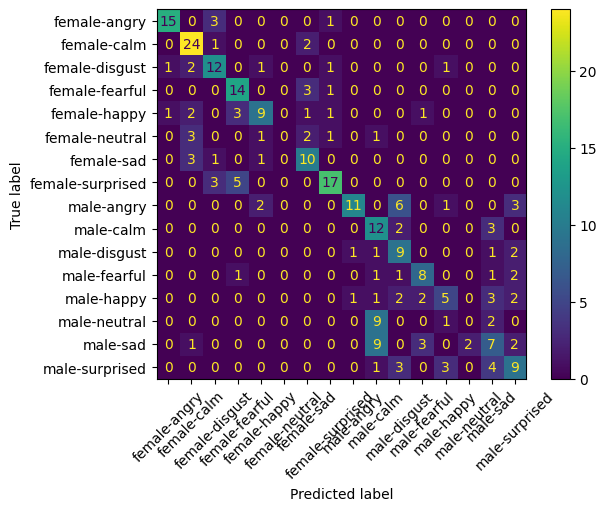

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(xticks_rotation=45)

